# B1 — Bouaké DE extraction (ABCs gambiae, OBPs coluzzii)

Extract DE ABC transporters (gambiae PM contrast) and DE odorant-binding proteins (coluzzii PM contrast) from the paper's DESeq2 results, annotated via AnoExpress PFAM/GO.

Outputs:
- `results/abc_obp/bouake_de_abc_gambiae.csv`
- `results/abc_obp/bouake_de_obp_coluzzii.csv`
- Interactive volcano highlight plots.

In [1]:
import os
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import anoexpress as ae

os.makedirs("results/abc_obp", exist_ok=True)
os.makedirs("figures_ms", exist_ok=True)

DE_PATH = "results/BouakePM_diffexp.xlsx"
xl = pd.ExcelFile(DE_PATH)
print("sheets:", xl.sheet_names)

gam = xl.parse("gambiaeCont_gambiaePM")
col = xl.parse("coluzziiCont_coluzziiPM")
print("gambiae shape:", gam.shape, " coluzzii shape:", col.shape)

sheets: ['Kisumu_gambiaeCont', 'gambiaeCont_gambiaePM', 'Ngousso_coluzziiCont', 'coluzziiCont_coluzziiPM']


gambiae shape: (13796, 12)  coluzzii shape: (13796, 12)


In [2]:
# AnoExpress annotations (PFAM + GO) — aggregate per gene
ann = ae.load_annotations()
print("ann shape:", ann.shape, " cols:", ann.columns.tolist())

# Aggregate PFAM domains + GO terms per gene_id
ann_by_gene = (
    ann.groupby("gene_id")
    .agg(
        pfam_domains=("pfamid", lambda x: ";".join(sorted(set(str(v) for v in x if pd.notna(v))))),
        go_terms=("GO_terms", lambda x: ";".join(sorted(set(
            t.strip()
            for v in x if pd.notna(v)
            for t in str(v).split(";") if t.strip()
        )))),
    )
    .reset_index()
)
print("ann_by_gene:", ann_by_gene.shape)
ann_by_gene.head(3)

ann shape: (19499, 8)  cols: ['transcript', 'pstart', 'pend', 'pfamid', 'domain', 'domseq', 'GO_terms', 'gene_id']


ann_by_gene: (10179, 3)


,gene_id,pfam_domains,go_terms
0,AGAP000002,PF00397,
1,AGAP000005,PF00505;PF09011,"GO:0000122,GO:0002682,GO:0002683,GO:0002759,GO..."
2,AGAP000007,PF00041;PF00059;PF07679;PF13927,"GO:0000003,GO:0000226,GO:0000902,GO:0000904,GO..."


In [3]:
# PFAM IDs for ABC_tran and PBP_GOBP families (use domain name to resolve)
def pfam_ids_for(domain_name):
    return sorted(ann.loc[ann["domain"].astype(str).str.contains(domain_name, case=False, na=False), "pfamid"].dropna().unique())

abc_pfam_ids = pfam_ids_for("ABC_tran")
obp_pfam_ids = pfam_ids_for("PBP_GOBP")
print("ABC_tran pfam ids:", abc_pfam_ids)
print("PBP_GOBP pfam ids:", obp_pfam_ids)

# Additional related PFAMs
abc2_pfam_ids = pfam_ids_for("ABC2_membrane")
print("ABC2_membrane pfam ids:", abc2_pfam_ids)

# GO term of interest
# efflux: GO:0042626 (ATPase-coupled transmembrane transporter activity, across plasma membrane)
# transmembrane transport: GO:0055085
# odorant binding: GO:0005549
GO_ABC = ["GO:0042626", "GO:0055085"]
GO_OBP = ["GO:0005549"]

ABC_tran pfam ids: ['PF00005', 'PF09822', 'PF12848']
PBP_GOBP pfam ids: ['PF01395']
ABC2_membrane pfam ids: ['PF01061', 'PF12698']


In [4]:
# Build ABC and OBP gene sets via PFAM + GO
def has_any(s, needles):
    s = str(s)
    return any(n in s for n in needles)

abc_pfam_hits = set(ann_by_gene.loc[ann_by_gene["pfam_domains"].apply(lambda s: has_any(s, abc_pfam_ids + abc2_pfam_ids)), "gene_id"])
abc_go_hits   = set(ann_by_gene.loc[ann_by_gene["go_terms"].apply(lambda s: has_any(s, GO_ABC)), "gene_id"])
abc_genes = abc_pfam_hits | abc_go_hits

obp_pfam_hits = set(ann_by_gene.loc[ann_by_gene["pfam_domains"].apply(lambda s: has_any(s, obp_pfam_ids)), "gene_id"])
obp_go_hits   = set(ann_by_gene.loc[ann_by_gene["go_terms"].apply(lambda s: has_any(s, GO_OBP)), "gene_id"])
obp_genes = obp_pfam_hits | obp_go_hits

print(f"ABC genes: {len(abc_genes)} (pfam {len(abc_pfam_hits)}, GO {len(abc_go_hits)})")
print(f"OBP genes: {len(obp_genes)} (pfam {len(obp_pfam_hits)}, GO {len(obp_go_hits)})")

ABC genes: 592 (pfam 57, GO 578)
OBP genes: 46 (pfam 41, GO 20)


In [5]:
# GO:0055085 (transmembrane transport) is too broad — restrict to PFAM + GO:0042626 (ATPase-coupled efflux)
GO_ABC_STRICT = ["GO:0042626"]
abc_go_hits = set(ann_by_gene.loc[ann_by_gene["go_terms"].apply(lambda s: has_any(s, GO_ABC_STRICT)), "gene_id"])
abc_genes = abc_pfam_hits | abc_go_hits
print(f"ABC genes (PFAM + GO:0042626): {len(abc_genes)} (pfam {len(abc_pfam_hits)}, GO {len(abc_go_hits)}, overlap {len(abc_pfam_hits & abc_go_hits)})")

# Sanity: how many ABC-named genes are in the DE tables?
gam_abc_by_name = gam[gam["GeneName"].astype(str).str.contains(r"^Abc", case=False, na=False, regex=True)]
print(f"gambiae genes with Abc* name: {len(gam_abc_by_name)}")
col_obp_by_name = col[col["GeneName"].astype(str).str.contains("obp", case=False, na=False, regex=False)]
print(f"coluzzii genes with *obp* name: {len(col_obp_by_name)}")

ABC genes (PFAM + GO:0042626): 106 (pfam 57, GO 92, overlap 43)
gambiae genes with Abc* name: 45
coluzzii genes with *obp* name: 64


In [6]:
# Merge DE tables with ABC/OBP gene annotations
def annotate_with(df, gene_set, family_label, name_regex=None):
    out = df.copy()
    in_set = out["GeneID"].isin(gene_set)
    if name_regex is not None:
        in_name = out["GeneName"].astype(str).str.contains(name_regex, case=False, na=False, regex=True)
        out["family_source"] = np.where(in_set & in_name, "pfam_go+name",
                                np.where(in_set, "pfam_go",
                                np.where(in_name, "name", "")))
        keep = in_set | in_name
    else:
        out["family_source"] = np.where(in_set, "pfam_go", "")
        keep = in_set
    out = out.loc[keep].copy()
    out["family"] = family_label
    return out.merge(ann_by_gene, left_on="GeneID", right_on="gene_id", how="left").drop(columns=["gene_id"])

abc_gam = annotate_with(gam, abc_genes, "ABC", name_regex=r"^Abc")
obp_col = annotate_with(col, obp_genes, "OBP", name_regex=r"obp|OBP")

print("ABC gambiae rows:", len(abc_gam), " |  significant padj<0.05:",
      int((abc_gam["padj"] < 0.05).sum()))
print("OBP coluzzii rows:", len(obp_col), " |  significant padj<0.05:",
      int((obp_col["padj"] < 0.05).sum()))

abc_gam_sorted = abc_gam.sort_values("log2FoldChange", ascending=False)
obp_col_sorted = obp_col.sort_values("log2FoldChange", ascending=False)
abc_gam_sorted.head(10)[["GeneID","GeneName","log2FoldChange","padj","family_source","pfam_domains"]]

ABC gambiae rows: 99  |  significant padj<0.05: 35
OBP coluzzii rows: 74  |  significant padj<0.05: 17


,GeneID,GeneName,log2FoldChange,padj,family_source,pfam_domains
9,AGAP008436,ABCC11,2.263626,9.891000e-07,pfam_go+name,PF00005;PF00664
3,AGAP008437,ABCC9,1.902601,5.580121e-10,pfam_go+name,PF00005;PF00664
8,AGAP006380,ABCA2,1.837999,3.065699e-07,pfam_go+name,PF00005;PF12698
11,AGAP012156,ABCA5,1.775297,1.492250e-05,pfam_go+name,PF00005;PF12698
0,AGAP009463,ABCG11,1.491962,4.895114e-16,pfam_go+name,PF00005;PF01061
4,AGAP000390,NaN,1.432777,1.659320e-09,pfam_go,PF00122;PF00702;PF13246;PF16209;PF16212
6,AGAP027980,NaN,1.289861,1.824852e-07,pfam_go,PF00005;PF00664
1,AGAP002638,ABCH1,1.231517,3.939473e-14,pfam_go+name,PF00005;PF12698
33,AGAP008539,NaN,1.015792,4.588508e-02,pfam_go,PF04280
2,AGAP009472,ABCG20,1.013553,1.905599e-13,pfam_go+name,PF00005;PF01061


In [8]:
obp_col_sorted.head(15)[["GeneID","GeneName","log2FoldChange","padj","family_source","pfam_domains"]]

,GeneID,GeneName,log2FoldChange,padj,family_source,pfam_domains
64,AGAP009065,OBP42,2.987931,NaN,pfam_go+name,PF01395
65,AGAP010648,OBP44,2.565146,NaN,name,NaN
27,AGAP012714,Obp72,2.039901,2.827987e-01,pfam_go+name,PF01395
0,AGAP009629,OBP5,1.714811,7.427305e-12,pfam_go+name,PF01395
8,AGAP006074,Obp71,1.674194,3.119480e-05,name,NaN
12,AGAP011367,OBP56,1.613969,9.384893e-03,pfam_go+name,PF01395
1,AGAP029062,NaN,1.613284,2.540802e-11,pfam_go,PF01395
2,AGAP001409,OBP3,1.576134,4.642937e-11,pfam_go+name,PF01395
6,AGAP003306,OBP2,1.542303,2.009396e-06,pfam_go+name,PF01395
58,AGAP005182,OBP41,1.529204,NaN,pfam_go+name,PF01395


In [7]:
# Save ranked tables
abc_gam_sorted.to_csv("results/abc_obp/bouake_de_abc_gambiae.csv", index=False)
obp_col_sorted.to_csv("results/abc_obp/bouake_de_obp_coluzzii.csv", index=False)

# Also save cross-species versions (ABCs in coluzzii, OBPs in gambiae) for reference/supplement
abc_col = annotate_with(col, abc_genes, "ABC", name_regex=r"^Abc").sort_values("log2FoldChange", ascending=False)
obp_gam = annotate_with(gam, obp_genes, "OBP", name_regex=r"obp|OBP").sort_values("log2FoldChange", ascending=False)
abc_col.to_csv("results/abc_obp/bouake_de_abc_coluzzii.csv", index=False)
obp_gam.to_csv("results/abc_obp/bouake_de_obp_gambiae.csv", index=False)

print("Saved:")
for f in ["bouake_de_abc_gambiae.csv","bouake_de_obp_coluzzii.csv","bouake_de_abc_coluzzii.csv","bouake_de_obp_gambiae.csv"]:
    print(" ", f)

# Summary counts by significance
def summary(df, label):
    n = len(df); nsig = int((df["padj"]<0.05).sum()); nup = int(((df["padj"]<0.05) & (df["log2FoldChange"]>0)).sum()); ndn = int(((df["padj"]<0.05) & (df["log2FoldChange"]<0)).sum())
    print(f"{label}: n={n}, sig={nsig} (up={nup}, down={ndn})")
summary(abc_gam_sorted, "ABC gambiae (PM vs Cont)")
summary(obp_col_sorted, "OBP coluzzii (PM vs Cont)")
summary(abc_col,        "ABC coluzzii  (PM vs Cont)")
summary(obp_gam,        "OBP gambiae  (PM vs Cont)")

Saved:
  bouake_de_abc_gambiae.csv
  bouake_de_obp_coluzzii.csv
  bouake_de_abc_coluzzii.csv
  bouake_de_obp_gambiae.csv
ABC gambiae (PM vs Cont): n=99, sig=35 (up=30, down=5)
OBP coluzzii (PM vs Cont): n=74, sig=17 (up=16, down=1)
ABC coluzzii  (PM vs Cont): n=99, sig=32 (up=6, down=26)
OBP gambiae  (PM vs Cont): n=74, sig=19 (up=17, down=2)


/var/folders/yd/tz1zj4195ybgmg97z4y695w40000gp/T/ipykernel_20722/2397478670.py:34: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(f"figures_ms/{out_stub}.png", scale=2)


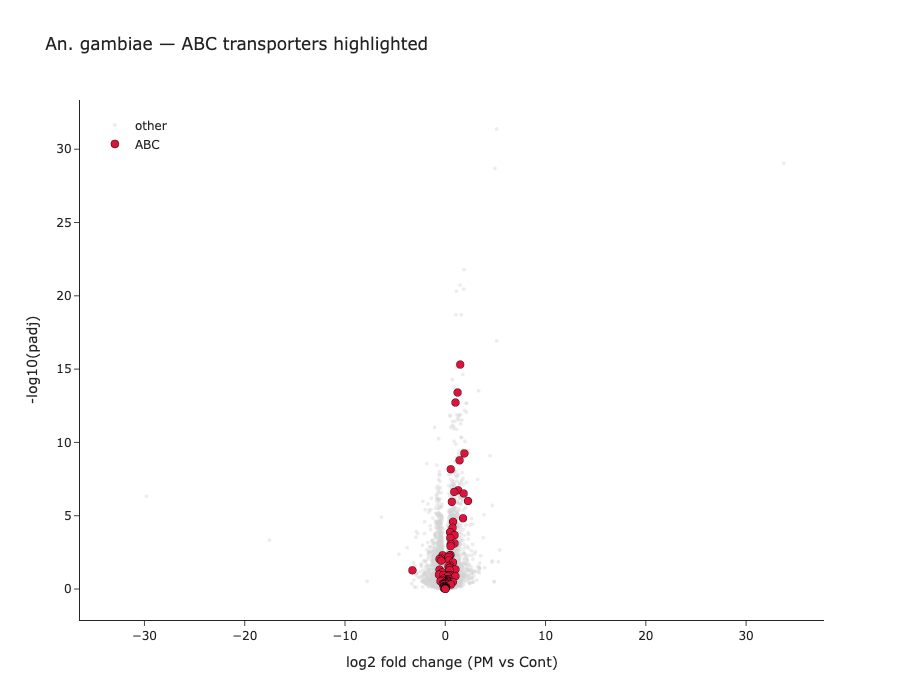

In [8]:
# Interactive volcano plot — gambiae with ABCs highlighted
def volcano_highlight(de_df, highlight_df, title, family_label, out_stub, width=900, height=700):
    d = de_df.copy()
    d["neglog10padj"] = -np.log10(d["padj"].clip(lower=1e-300))
    d["highlight"] = d["GeneID"].isin(set(highlight_df["GeneID"]))
    d["label"] = np.where(d["GeneName"].isna(), d["GeneID"], d["GeneName"].astype(str))

    bg = d[~d["highlight"]]
    fg = d[d["highlight"]]

    fig = go.Figure()
    fig.add_trace(go.Scattergl(
        x=bg["log2FoldChange"], y=bg["neglog10padj"],
        mode="markers", name="other",
        marker=dict(size=4, color="lightgrey", opacity=0.4),
        hoverinfo="skip",
    ))
    fig.add_trace(go.Scattergl(
        x=fg["log2FoldChange"], y=fg["neglog10padj"],
        mode="markers", name=family_label,
        marker=dict(size=8, color="crimson", line=dict(color="black", width=0.5)),
        text=fg["label"],
        customdata=fg[["GeneID","padj"]].values,
        hovertemplate="<b>%{text}</b><br>GeneID: %{customdata[0]}<br>log2FC: %{x:.2f}<br>padj: %{customdata[1]:.2e}<extra></extra>",
    ))
    fig.add_hline(y=-np.log10(0.05), line_dash="dash", line_color="grey")
    fig.add_vline(x=0, line_dash="dot", line_color="grey")
    fig.update_layout(
        title=title, xaxis_title="log2 fold change (PM vs Cont)",
        yaxis_title="-log10(padj)", width=width, height=height,
        template="simple_white", legend=dict(x=0.02, y=0.98),
    )
    fig.write_html(f"figures_ms/{out_stub}.html")
    fig.write_image(f"figures_ms/{out_stub}.png", scale=2)
    return fig

fig_abc = volcano_highlight(gam, abc_gam_sorted, "An. gambiae — ABC transporters highlighted", "ABC", "b1_volcano_abc_gambiae")
fig_abc.show()

/var/folders/yd/tz1zj4195ybgmg97z4y695w40000gp/T/ipykernel_20722/2397478670.py:34: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(f"figures_ms/{out_stub}.png", scale=2)


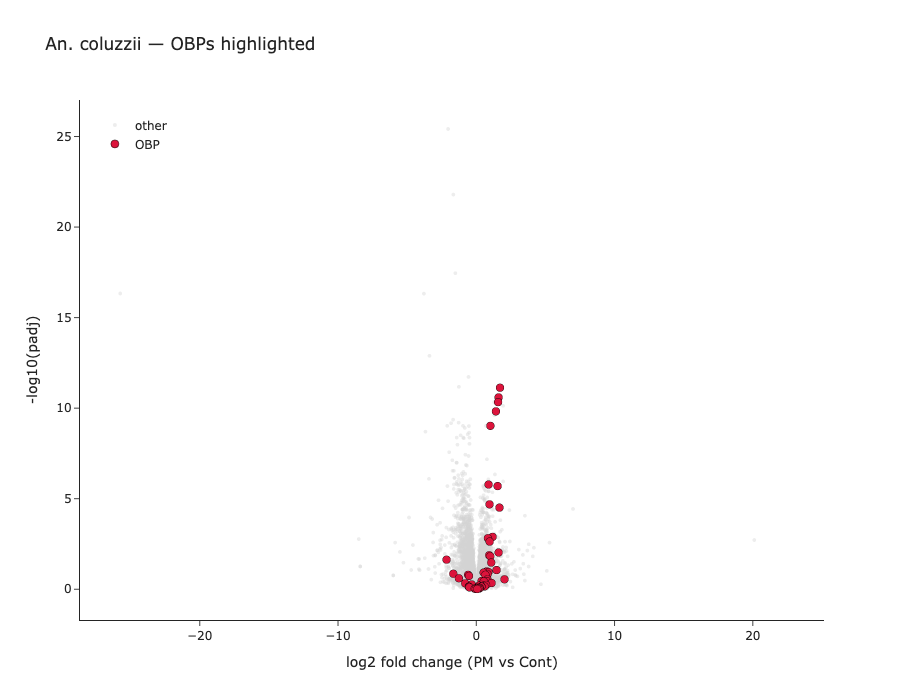

In [9]:
fig_obp = volcano_highlight(col, obp_col_sorted, "An. coluzzii — OBPs highlighted", "OBP", "b1_volcano_obp_coluzzii")
fig_obp.show()

In [10]:
# Horizontal bar plot of top DE members (|log2FC|, coloured by padj)
def family_bar(df, title, family_label, out_stub, n=25, width=900, height=700):
    d = df.copy()
    d["label"] = np.where(d["GeneName"].isna(), d["GeneID"], d["GeneName"].astype(str) + " (" + d["GeneID"] + ")")
    d = d.dropna(subset=["log2FoldChange"])
    d = d.reindex(d["log2FoldChange"].abs().sort_values(ascending=False).index).head(n)
    d = d.sort_values("log2FoldChange")

    d["sig"] = d["padj"] < 0.05
    fig = go.Figure()
    fig.add_trace(go.Bar(
        y=d["label"], x=d["log2FoldChange"], orientation="h",
        marker=dict(
            color=d["log2FoldChange"],
            colorscale="RdBu_r", cmid=0,
            line=dict(color=np.where(d["sig"], "black", "lightgrey"),
                      width=np.where(d["sig"], 1.2, 0.3)),
        ),
        customdata=d[["GeneID","padj","pfam_domains"]].values,
        hovertemplate="<b>%{y}</b><br>log2FC: %{x:.2f}<br>padj: %{customdata[1]:.2e}<br>PFAM: %{customdata[2]}<extra></extra>",
    ))
    fig.add_vline(x=0, line_color="grey")
    fig.update_layout(
        title=title, xaxis_title="log2 fold change (PM vs Cont)",
        yaxis_title=family_label, template="simple_white",
        width=width, height=height, showlegend=False,
    )
    fig.write_html(f"figures_ms/{out_stub}.html")
    fig.write_image(f"figures_ms/{out_stub}.png", scale=2)
    return fig

fig_abc_bar = family_bar(abc_gam_sorted, "Top DE ABC transporters — An. gambiae (Bouaké)", "ABC", "b1_bar_abc_gambiae")
fig_abc_bar.show()

/var/folders/yd/tz1zj4195ybgmg97z4y695w40000gp/T/ipykernel_20722/4193999327.py:29: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(f"figures_ms/{out_stub}.png", scale=2)


In [11]:
fig_obp_bar = family_bar(obp_col_sorted, "Top DE OBPs — An. coluzzii (Bouaké)", "OBP", "b1_bar_obp_coluzzii")
fig_obp_bar.show()

/var/folders/yd/tz1zj4195ybgmg97z4y695w40000gp/T/ipykernel_20722/4193999327.py:29: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(f"figures_ms/{out_stub}.png", scale=2)


In [12]:
# Side-by-side species-asymmetry check: ABC / OBP log2FC in gambiae vs coluzzii
def species_scatter(df_a, df_b, family, out_stub, width=800, height=700):
    a = df_a[["GeneID","GeneName","log2FoldChange","padj"]].rename(columns={"log2FoldChange":"l2fc_gam","padj":"padj_gam"})
    b = df_b[["GeneID","log2FoldChange","padj"]].rename(columns={"log2FoldChange":"l2fc_col","padj":"padj_col"})
    m = a.merge(b, on="GeneID", how="inner")
    m["label"] = np.where(m["GeneName"].isna(), m["GeneID"], m["GeneName"].astype(str))
    m["sig_both"] = (m["padj_gam"]<0.05) & (m["padj_col"]<0.05)
    m["sig_gam_only"] = (m["padj_gam"]<0.05) & ~(m["padj_col"]<0.05)
    m["sig_col_only"] = (m["padj_col"]<0.05) & ~(m["padj_gam"]<0.05)

    def cat(row):
        if row["sig_both"]: return "both"
        if row["sig_gam_only"]: return "gambiae only"
        if row["sig_col_only"]: return "coluzzii only"
        return "neither"
    m["cat"] = m.apply(cat, axis=1)
    colmap = {"both":"#222","gambiae only":"#1f77b4","coluzzii only":"#d62728","neither":"lightgrey"}

    fig = go.Figure()
    for k,c in colmap.items():
        s = m[m["cat"]==k]
        fig.add_trace(go.Scatter(
            x=s["l2fc_gam"], y=s["l2fc_col"], mode="markers",
            name=k, marker=dict(size=9, color=c, line=dict(color="black",width=0.3)),
            text=s["label"],
            customdata=s[["GeneID","padj_gam","padj_col"]].values,
            hovertemplate="<b>%{text}</b><br>%{customdata[0]}<br>l2FC gam: %{x:.2f} (padj %{customdata[1]:.2e})<br>l2FC col: %{y:.2f} (padj %{customdata[2]:.2e})<extra></extra>",
        ))
    lim = max(abs(m["l2fc_gam"]).max(), abs(m["l2fc_col"]).max()) * 1.1
    fig.add_shape(type="line", x0=-lim, y0=-lim, x1=lim, y1=lim, line=dict(color="grey",dash="dot"))
    fig.add_hline(y=0, line_color="grey", line_dash="dot")
    fig.add_vline(x=0, line_color="grey", line_dash="dot")
    fig.update_layout(
        title=f"{family} — log2FC gambiae vs coluzzii (Bouaké PM vs Cont)",
        xaxis_title="gambiae log2FC", yaxis_title="coluzzii log2FC",
        template="simple_white", width=width, height=height,
        xaxis=dict(range=[-lim,lim]), yaxis=dict(range=[-lim,lim]),
    )
    fig.write_html(f"figures_ms/{out_stub}.html")
    fig.write_image(f"figures_ms/{out_stub}.png", scale=2)
    return fig

fig_abc_asym = species_scatter(abc_gam, abc_col, "ABC transporters", "b1_species_scatter_abc")
fig_abc_asym.show()

/var/folders/yd/tz1zj4195ybgmg97z4y695w40000gp/T/ipykernel_20722/1293299496.py:40: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(f"figures_ms/{out_stub}.png", scale=2)


In [13]:
fig_obp_asym = species_scatter(obp_gam, obp_col, "OBPs", "b1_species_scatter_obp")
fig_obp_asym.show()

/var/folders/yd/tz1zj4195ybgmg97z4y695w40000gp/T/ipykernel_20722/1293299496.py:40: DeprecationWarning: 
Support for Kaleido versions less than 1.0.0 is deprecated and will be removed after September 2025.
Please upgrade Kaleido to version 1.0.0 or greater (`pip install 'kaleido>=1.0.0'` or `pip install 'plotly[kaleido]'`).

  fig.write_image(f"figures_ms/{out_stub}.png", scale=2)
